# Hoja de trabajo 2 — Transformers y mecanismos de atención

**CC3092 · Deep Learning y Sistemas Inteligentes** — Esteban Cárcamo (23016)

Contenido del notebook:

1. **Atención desde cero**: scaled dot-product attention y multi-head attention, ejercicio a mano y verificación contra `F.scaled_dot_product_attention` y `nn.MultiheadAttention`.
2. **Escalamiento por √d_k**: varianza de q·k y saturación de la softmax.
3. **Costo computacional**: tiempo y memoria de la atención frente a la longitud n.
4. **Atención en BERT y GPT-2** (sección 5): patrones por cabeza, el par «it → animal / street», matriz causal y *attention sinks*, entropía por capa, ablación de cabezas y bertviz.

Las figuras se guardan en `results/figures/` y las cifras del informe en `results/results.json`.

In [1]:
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, GPT2LMHeadModel
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS = {}
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    plt.show()


print(DEVICE, torch.__version__, torch.cuda.get_device_name() if DEVICE.type == "cuda" else "")

cuda 2.13.0+cu130 NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Atención desde cero

$$\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

`attention` recibe tensores `(..., n, d_k)`, aplica opcionalmente una máscara causal (triangular inferior) o una máscara booleana
(`True` = se puede atender, misma convención que `F.scaled_dot_product_attention`) y devuelve la salida y los pesos.

In [2]:
def attention(q, k, v, mask=None, causal=False, scale=None):
    scale = 1 / math.sqrt(q.size(-1)) if scale is None else scale
    scores = q @ k.transpose(-2, -1) * scale
    if causal:
        n, m = scores.shape[-2:]
        allowed = torch.ones(n, m, dtype=torch.bool, device=q.device).tril()
        scores = scores.masked_fill(~allowed, float("-inf"))
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf")) if mask.dtype == torch.bool else scores + mask
    weights = scores.softmax(dim=-1)
    return weights @ v, weights

### 1.1 Ejercicio a mano

Tres tokens con $d_{model}=d_k=2$. Se calcula $Q=XW_Q$, $K=XW_K$, $V=XW_V$, los puntajes $QK^\top/\sqrt 2$, la softmax por fila y la salida.
El mismo procedimiento está desarrollado paso a paso en el informe; aquí se verifica numéricamente, con y sin máscara causal.

In [3]:
X = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
W_q = torch.tensor([[1., 0.], [1., 1.]])
W_k = torch.tensor([[1., 1.], [0., 1.]])
W_v = torch.tensor([[1., 0.], [0., 2.]])

Q, K, V = X @ W_q, X @ W_k, X @ W_v
scores = Q @ K.T
scaled = scores / math.sqrt(2)
out, weights = attention(Q, K, V)
out_causal, weights_causal = attention(Q, K, V, causal=True)

torch.set_printoptions(precision=3, sci_mode=False)
for name, value in [("Q", Q), ("K", K), ("V", V), ("QK^T", scores), ("QK^T/sqrt(2)", scaled),
                    ("exp", scaled.exp()), ("pesos", weights), ("salida", out),
                    ("pesos causales", weights_causal), ("salida causal", out_causal)]:
    print(f"{name}:\n{value}\n")

RESULTS["hand_exercise"] = {name: value.tolist() for name, value in
                            [("Q", Q), ("K", K), ("V", V), ("scores", scores), ("scaled", scaled),
                             ("weights", weights), ("output", out),
                             ("weights_causal", weights_causal), ("output_causal", out_causal)]}

Q:
tensor([[1., 0.],
        [1., 1.],
        [2., 1.]])

K:
tensor([[1., 1.],
        [0., 1.],
        [1., 2.]])

V:
tensor([[1., 0.],
        [0., 2.],
        [1., 2.]])

QK^T:
tensor([[1., 0., 1.],
        [2., 1., 3.],
        [3., 1., 4.]])

QK^T/sqrt(2):
tensor([[0.707, 0.000, 0.707],
        [1.414, 0.707, 2.121],
        [2.121, 0.707, 2.828]])

exp:
tensor([[ 2.028,  1.000,  2.028],
        [ 4.113,  2.028,  8.342],
        [ 8.342,  2.028, 16.919]])

pesos:
tensor([[0.401, 0.198, 0.401],
        [0.284, 0.140, 0.576],
        [0.306, 0.074, 0.620]])

salida:
tensor([[0.802, 1.198],
        [0.860, 1.432],
        [0.926, 1.389]])

pesos causales:
tensor([[1.000, 0.000, 0.000],
        [0.670, 0.330, 0.000],
        [0.306, 0.074, 0.620]])

salida causal:
tensor([[1.000, 0.000],
        [0.670, 0.660],
        [0.926, 1.389]])



**Interpretación.** Cada fila de pesos suma 1. El token 3 ($q_3=[2,1]$) tiene su mayor puntaje con $k_3=[1,2]$ (4/√2 = 2.83), así que le da 0.62 de su
atención y su salida queda cerca de $v_3$. Con máscara causal el token 1 solo puede verse a sí mismo (peso 1) y su salida es exactamente $v_1$.

### 1.2 Verificación contra `F.scaled_dot_product_attention`

Con tensores aleatorios `(batch=2, heads=4, n=10, d_k=16)` se compara la implementación propia sin máscara, con máscara causal (`is_causal`),
con una máscara booleana de padding (`attn_mask`) y con una escala distinta (`scale`). `dropout_p` solo se usa en entrenamiento y no es
determinista, así que se deja en 0.

In [4]:
q, k, v = (torch.randn(2, 4, 10, 16) for _ in range(3))
padding = torch.ones(2, 1, 1, 10, dtype=torch.bool)
padding[1, ..., 7:] = False

checks = {
    "sin máscara": (attention(q, k, v)[0], F.scaled_dot_product_attention(q, k, v)),
    "is_causal": (attention(q, k, v, causal=True)[0], F.scaled_dot_product_attention(q, k, v, is_causal=True)),
    "attn_mask (padding)": (attention(q, k, v, mask=padding)[0], F.scaled_dot_product_attention(q, k, v, attn_mask=padding)),
    "scale=0.5": (attention(q, k, v, scale=0.5)[0], F.scaled_dot_product_attention(q, k, v, scale=0.5)),
}
RESULTS["sdpa_max_error"] = {}
for name, (own, ref) in checks.items():
    err = (own - ref).abs().max().item()
    RESULTS["sdpa_max_error"][name] = err
    print(f"{name:22s} error máximo = {err:.2e}  allclose = {torch.allclose(own, ref, atol=1e-6)}")

sin máscara            error máximo = 3.58e-07  allclose = True
is_causal              error máximo = 2.38e-07  allclose = True
attn_mask (padding)    error máximo = 3.58e-07  allclose = True
scale=0.5              error máximo = 4.77e-07  allclose = True


**Interpretación.** Los errores son del orden de $10^{-7}$, la precisión de float32: la implementación propia coincide con la de PyTorch en los cuatro casos.

### 1.3 Multi-head attention propia vs `nn.MultiheadAttention`

Una sola proyección lineal produce Q, K y V; se parten en `h` cabezas de `d_model/h`, se aplica `attention` a cada una en paralelo,
se concatenan y pasan por `W_O`. Se copian los pesos de `nn.MultiheadAttention` (`in_proj_weight` guarda Q, K y V apilados en ese orden)
y se comparan salidas y pesos por cabeza (`average_attn_weights=False`) con máscara causal y `key_padding_mask`.
Ojo con las convenciones: en `nn.MultiheadAttention` una máscara booleana con `True` significa **no** atender.

In [5]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads, self.d_k = num_heads, d_model // num_heads
        self.w_qkv = nn.Linear(d_model, 3 * d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, causal=False, key_padding_mask=None):
        b, n, d = x.shape
        q, k, v = self.w_qkv(x).view(b, n, 3, self.num_heads, self.d_k).permute(2, 0, 3, 1, 4)
        mask = None if key_padding_mask is None else ~key_padding_mask[:, None, None, :]
        out, weights = attention(q, k, v, mask=mask, causal=causal)
        return self.w_o(out.transpose(1, 2).reshape(b, n, d)), weights


d_model, num_heads, n = 64, 8, 12
reference = nn.MultiheadAttention(d_model, num_heads, batch_first=True).eval()
own = MultiHeadSelfAttention(d_model, num_heads).eval()
with torch.no_grad():
    own.w_qkv.weight.copy_(reference.in_proj_weight)
    own.w_qkv.bias.copy_(reference.in_proj_bias)
    own.w_o.weight.copy_(reference.out_proj.weight)
    own.w_o.bias.copy_(reference.out_proj.bias)

x = torch.randn(3, n, d_model)
key_padding_mask = torch.zeros(3, n, dtype=torch.bool)
key_padding_mask[2, 9:] = True
causal_mask = nn.Transformer.generate_square_subsequent_mask(n)
print("generate_square_subsequent_mask(4):\n", nn.Transformer.generate_square_subsequent_mask(4))

with torch.no_grad():
    ref_out, ref_w = reference(x, x, x, attn_mask=causal_mask, key_padding_mask=key_padding_mask,
                               need_weights=True, average_attn_weights=False)
    own_out, own_w = own(x, causal=True, key_padding_mask=key_padding_mask)

RESULTS["mha_max_error"] = {"output": (own_out - ref_out).abs().max().item(),
                            "weights": (own_w - ref_w).abs().max().item()}
print(RESULTS["mha_max_error"], ref_w.shape)

params = {h: sum(p.numel() for p in nn.MultiheadAttention(512, h).parameters()) for h in (1, 8, 16)}
RESULTS["mha_params_d512"] = params
print("parámetros con d_model=512:", params)

generate_square_subsequent_mask(4):
 tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])
{'output': 1.1920928955078125e-07, 'weights': 5.960464477539063e-08} torch.Size([3, 8, 12, 12])
parámetros con d_model=512: {1: 1050624, 8: 1050624, 16: 1050624}


/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING_CURSO/DEEP_LEARNING/venv/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


**Interpretación.** Salidas y pesos coinciden (error ~$10^{-7}$). El número de parámetros es el mismo con 1, 8 o 16 cabezas
($4d^2+4d$ = 1 050 624 con $d=512$): $h$ solo decide cómo se reparte $d_{model}$, no cuántos pesos hay.

`nn.TransformerEncoderLayer` junta todo el bloque: atención multi-cabeza + residual + LayerNorm + FFN por posición + residual + LayerNorm.
`norm_first=False` es Post-LN (artículo original) y `norm_first=True` es Pre-LN. Para ver la diferencia se apilan 24 capas de cada tipo
y se mide la norma del gradiente (pérdida MSE contra un objetivo aleatorio) que llega a los parámetros de cada capa al inicializar.

In [6]:
def layer_grad_norms(norm_first, depth=24, d_model=128):
    torch.manual_seed(0)
    layer = nn.TransformerEncoderLayer(d_model, nhead=4, dim_feedforward=4 * d_model, dropout=0.0,
                                       batch_first=True, norm_first=norm_first)
    final_norm = nn.LayerNorm(d_model) if norm_first else None
    encoder = nn.TransformerEncoder(layer, num_layers=depth, norm=final_norm, enable_nested_tensor=False)
    x, target = torch.randn(8, 32, d_model), torch.randn(8, 32, d_model)
    out = encoder(x, mask=nn.Transformer.generate_square_subsequent_mask(32), is_causal=True)
    F.mse_loss(out, target).backward()
    return [math.sqrt(sum(p.grad.pow(2).sum().item() for p in l.parameters())) for l in encoder.layers]


grad_norms = {"Post-LN": layer_grad_norms(False), "Pre-LN": layer_grad_norms(True)}
RESULTS["ln_grad_norms"] = grad_norms
for name, values in grad_norms.items():
    print(f"{name}: capa 1 = {values[0]:.4f}, capa 12 = {values[11]:.4f}, capa 24 = {values[-1]:.4f}, "
          f"razón última/primera = {values[-1] / values[0]:.2f}")

Post-LN: capa 1 = 0.0464, capa 12 = 0.0361, capa 24 = 0.3522, razón última/primera = 7.59
Pre-LN: capa 1 = 0.1064, capa 12 = 0.0232, capa 24 = 0.0188, razón última/primera = 0.18


**Interpretación.** En Post-LN el gradiente se concentra cerca de la salida (la capa 24 recibe ~7.6 veces más que la primera), por eso el artículo
original necesita *warm-up* del learning rate. En Pre-LN el camino residual es una identidad limpia y la LayerNorm no se interpone en él, así que el
gradiente llega a las primeras capas sin atenuarse; por eso los modelos actuales (GPT-2 incluido) usan Pre-LN.

## 2. ¿Por qué dividir entre √d_k?

Si cada componente de q y k es independiente con media 0 y varianza 1, $q\cdot k=\sum_i q_ik_i$ es suma de $d_k$ términos con varianza 1,
así que $\text{Var}(q\cdot k)=d_k$. Se verifica empíricamente y se mide qué le pasa a la softmax sobre 32 llaves: la probabilidad máxima
y la norma de su jacobiano $\partial\,\text{softmax}/\partial s = \text{diag}(p)-pp^\top$, que es lo que multiplica al gradiente.

d_k=    4  Var(q·k)=     4.0  escalada=1.002  max p: 0.355 vs 0.163  ||J||: 0.2917 vs 0.2363
d_k=   16  Var(q·k)=    16.1  escalada=1.004  max p: 0.626 vs 0.163  ||J||: 0.2895 vs 0.2395
d_k=   64  Var(q·k)=    64.2  escalada=1.002  max p: 0.823 vs 0.165  ||J||: 0.1909 vs 0.2408
d_k=  256  Var(q·k)=   256.6  escalada=1.002  max p: 0.910 vs 0.165  ||J||: 0.1122 vs 0.2413
d_k= 1024  Var(q·k)=  1019.4  escalada=0.995  max p: 0.953 vs 0.164  ||J||: 0.0636 vs 0.2409


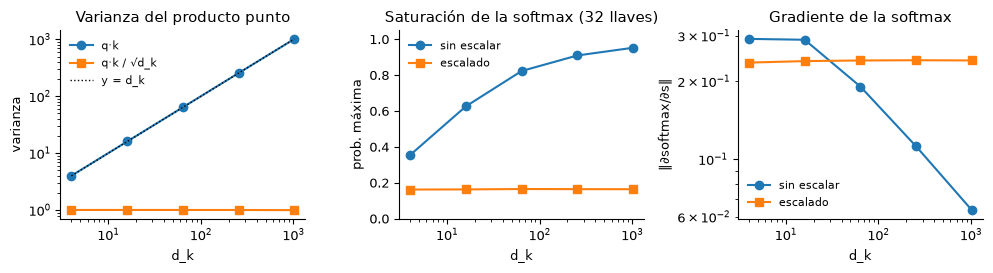

In [7]:
dims = [4, 16, 64, 256, 1024]
scaling = {"d_k": dims, "var_raw": [], "var_scaled": [], "max_p_raw": [], "max_p_scaled": [],
           "jac_raw": [], "jac_scaled": []}


def softmax_stats(s):
    p = s.softmax(-1)
    jac = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)
    return p.max(-1).values.mean().item(), jac.flatten(-2).norm(dim=-1).mean().item()


for d in dims:
    q = torch.randn(2000, 1, d)
    k = torch.randn(2000, 32, d)
    s = (q * k).sum(-1)
    scaling["var_raw"].append(s.var().item())
    scaling["var_scaled"].append((s / math.sqrt(d)).var().item())
    for tag, values in (("raw", s), ("scaled", s / math.sqrt(d))):
        max_p, jac = softmax_stats(values)
        scaling[f"max_p_{tag}"].append(max_p)
        scaling[f"jac_{tag}"].append(jac)
RESULTS["scaling"] = scaling
for i, d in enumerate(dims):
    print(f"d_k={d:5d}  Var(q·k)={scaling['var_raw'][i]:8.1f}  escalada={scaling['var_scaled'][i]:.3f}  "
          f"max p: {scaling['max_p_raw'][i]:.3f} vs {scaling['max_p_scaled'][i]:.3f}  "
          f"||J||: {scaling['jac_raw'][i]:.4f} vs {scaling['jac_scaled'][i]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8))
axes[0].loglog(dims, scaling["var_raw"], "o-", label="q·k")
axes[0].loglog(dims, scaling["var_scaled"], "s-", label="q·k / √d_k")
axes[0].loglog(dims, dims, "k:", lw=1, label="y = d_k")
axes[0].set(xlabel="d_k", ylabel="varianza", title="Varianza del producto punto")
axes[1].semilogx(dims, scaling["max_p_raw"], "o-", label="sin escalar")
axes[1].semilogx(dims, scaling["max_p_scaled"], "s-", label="escalado")
axes[1].set(xlabel="d_k", ylabel="prob. máxima", title="Saturación de la softmax (32 llaves)", ylim=(0, 1.05))
axes[2].loglog(dims, scaling["jac_raw"], "o-", label="sin escalar")
axes[2].loglog(dims, scaling["jac_scaled"], "s-", label="escalado")
axes[2].set(xlabel="d_k", ylabel="‖∂softmax/∂s‖", title="Gradiente de la softmax")
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save_fig(fig, "01_scaling")

**Interpretación.** La varianza de $q\cdot k$ es $d_k$ y al dividir entre $\sqrt{d_k}$ vuelve a 1 para cualquier dimensión. Sin escalar, con $d_k=1024$ la
softmax pone 0.95 de la probabilidad en una sola llave y la norma de su jacobiano cae a 0.06 (cuatro veces menos que escalada): la softmax se satura
y los gradientes se desvanecen. Escalada, la distribución y el gradiente no dependen de $d_k$.

## 3. Costo computacional frente a n

Se mide en GPU (fp16, batch 1, 8 cabezas, d_k = 64) el tiempo de forward (mediana de 30 repeticiones con eventos CUDA) y el pico de memoria de:
- la atención **ingenua** (la de arriba), que materializa la matriz n × n de puntajes y de pesos;
- `F.scaled_dot_product_attention`, que en GPU elige un kernel fusionado tipo **FlashAttention** y nunca guarda la matriz completa.

n=   256  ingenua: 0.06 ms, 10.4 MB   SDPA: 0.03 ms, 0.3 MB
n=   512  ingenua: 0.15 ms, 8.5 MB   SDPA: 0.08 ms, 0.5 MB
n=  1024  ingenua: 0.60 ms, 33.0 MB   SDPA: 0.27 ms, 1.0 MB
n=  2048  ingenua: 2.60 ms, 130.0 MB   SDPA: 0.92 ms, 2.1 MB


n=  4096  ingenua: 9.82 ms, 516.0 MB   SDPA: 1.45 ms, 4.1 MB


n=  8192  ingenua: 37.24 ms, 2056.0 MB   SDPA: 5.77 ms, 8.3 MB


[W1005 22:34:25.481386911 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 4294967296 bytes (free: 1569128448, total: 6137315328).
[W1005 22:34:25.481483428 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 4294967296 bytes (free: 1569128448, total: 6137315328).


n= 16384  ingenua: sin memoria (OOM)   SDPA: 23.05 ms, 16.5 MB


[W1005 22:34:26.327674291 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 5813764096, total: 6137315328).
[W1005 22:34:26.327811922 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 5813764096, total: 6137315328).


n= 32768  ingenua: sin memoria (OOM)   SDPA: 92.41 ms, 33.0 MB
pendientes log-log (n ≥ 2048): {'naive_ms': 1.92, 'naive_mb': 1.99, 'sdpa_ms': 1.73, 'sdpa_mb': 1.0}


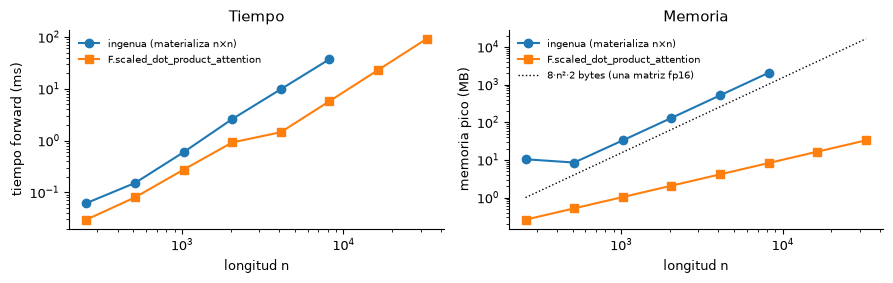

In [8]:
def benchmark(fn, n, heads=8, d_k=64, reps=30):
    q, k, v = (torch.randn(1, heads, n, d_k, device=DEVICE, dtype=torch.float16) for _ in range(3))
    torch.cuda.synchronize()
    base = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    try:
        for _ in range(5):
            fn(q, k, v)
        times = []
        for _ in range(reps):
            start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
            start.record()
            fn(q, k, v)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
        elapsed = float(np.median(times))
        memory = (torch.cuda.max_memory_allocated() - base) / 2**20
    except torch.OutOfMemoryError:
        elapsed, memory = None, None
    del q, k, v
    torch.cuda.empty_cache()
    return elapsed, memory


lengths = [256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
cost = {"n": lengths, "naive_ms": [], "naive_mb": [], "sdpa_ms": [], "sdpa_mb": []}
if DEVICE.type == "cuda":
    with torch.no_grad():
        for n in lengths:
            for tag, fn in (("naive", lambda q, k, v: attention(q, k, v)[0]), ("sdpa", F.scaled_dot_product_attention)):
                ms, mb = benchmark(fn, n)
                cost[f"{tag}_ms"].append(ms)
                cost[f"{tag}_mb"].append(mb)
            naive = "sin memoria (OOM)" if cost["naive_ms"][-1] is None else \
                f"{cost['naive_ms'][-1]:.2f} ms, {cost['naive_mb'][-1]:.1f} MB"
            print(f"n={n:6d}  ingenua: {naive}   SDPA: {cost['sdpa_ms'][-1]:.2f} ms, {cost['sdpa_mb'][-1]:.1f} MB")


def slope(xs, ys):
    pairs = [(x, y) for x, y in zip(xs, ys) if y is not None and x >= 2048]
    return float(np.polyfit(np.log([p[0] for p in pairs]), np.log([p[1] for p in pairs]), 1)[0])


cost["slopes"] = {key: slope(lengths, cost[key]) for key in ("naive_ms", "naive_mb", "sdpa_ms", "sdpa_mb")}
RESULTS["cost"] = cost
print("pendientes log-log (n ≥ 2048):", {k: round(v, 2) for k, v in cost["slopes"].items()})

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))
for tag, label, marker in (("naive", "ingenua (materializa n×n)", "o-"), ("sdpa", "F.scaled_dot_product_attention", "s-")):
    xs = [n for n, y in zip(lengths, cost[f"{tag}_ms"]) if y is not None]
    axes[0].loglog(xs, [y for y in cost[f"{tag}_ms"] if y is not None], marker, label=label)
    axes[1].loglog(xs, [y for y in cost[f"{tag}_mb"] if y is not None], marker, label=label)
ref_n = np.array(lengths, dtype=float)
axes[1].loglog(ref_n, 8 * ref_n**2 * 2 / 2**20, "k:", lw=1, label="8·n²·2 bytes (una matriz fp16)")
axes[0].set(xlabel="longitud n", ylabel="tiempo forward (ms)", title="Tiempo")
axes[1].set(xlabel="longitud n", ylabel="memoria pico (MB)", title="Memoria")
for ax in axes:
    ax.legend(frameon=False, fontsize=7.5)
fig.tight_layout()
save_fig(fig, "02_cost")

**Interpretación.** La atención ingenua crece con pendiente ≈ 2 en tiempo y en memoria ($O(n^2)$): con n = 8 192 ya ocupa 2 GB y con 16 384 se queda sin
memoria en una GPU de 6 GB. `F.scaled_dot_product_attention` (kernel tipo FlashAttention) sigue haciendo $O(n^2)$ operaciones, pero calcula la softmax por
bloques sin guardar la matriz, así que su memoria es lineal (pendiente 1.0): 33 MB con n = 32 768.

## 4. Atención en BERT y GPT-2

Se cargan los modelos de la sección 1 de la hoja con `output_attentions=True` y `attn_implementation="eager"` (las implementaciones fusionadas
no devuelven los pesos). Cada modelo devuelve una tupla con una matriz por capa de forma `batch × cabezas × n × n`.

In [9]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").to(DEVICE).eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").to(DEVICE).eval()


def get_attentions(model, tokenizer, text):
    enc = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    tokens = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(enc["input_ids"][0])]
    return torch.stack(out.attentions)[:, 0].float().cpu(), tokens


att, tokens = get_attentions(bert, tok_bert, "Attention is all you need.")
print(len(bert(**tok_bert("hi", return_tensors="pt").to(DEVICE)).attentions), "capas;", att.shape, tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

12 capas; torch.Size([12, 12, 8, 8]) ['[CLS]', 'attention', 'is', 'all', 'you', 'need', '.', '[SEP]']


### 4.1 Patrones por cabeza

Para cada cabeza se mide cuánta atención (promedio por fila) va al token **anterior**, al **siguiente**, a sí mismo, a **[CLS]** / primer token,
a **[SEP]**, a la **puntuación** y a **otras apariciones de la misma palabra**, promediando sobre varias oraciones. Luego se grafica la
cabeza más representativa de cada patrón en la oración elegida, sin repetir capa.

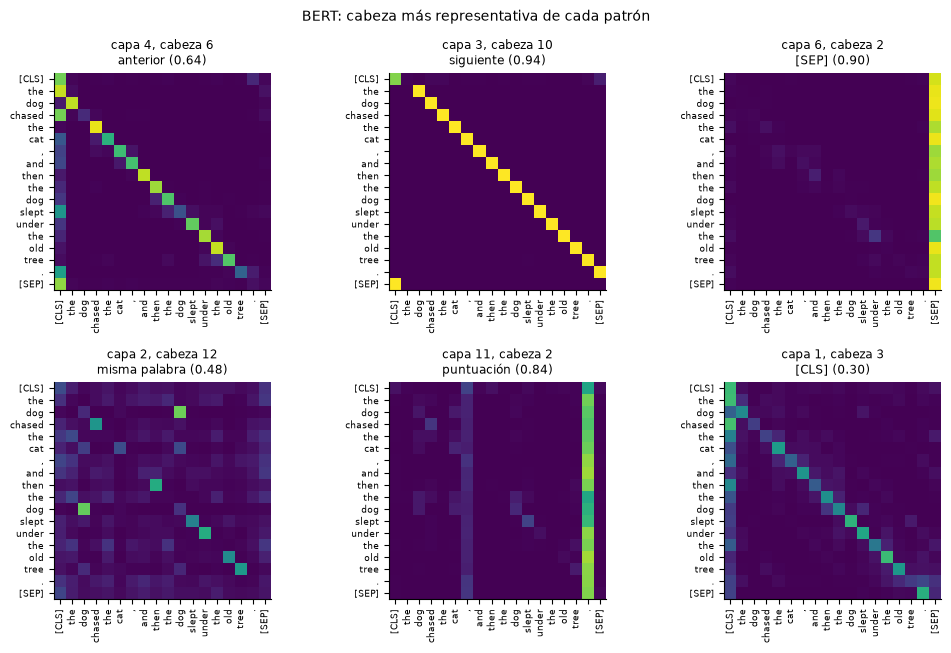

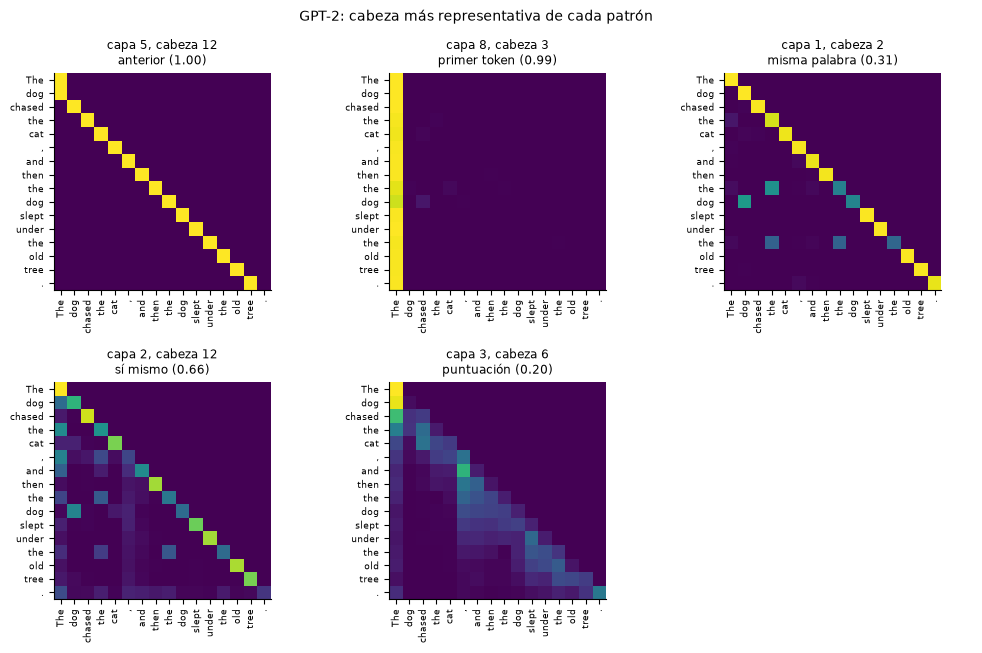

BERT   anterior       capa  4 cabeza  6  atención media = 0.64
BERT   siguiente      capa  3 cabeza 10  atención media = 0.94
BERT   [SEP]          capa  6 cabeza  2  atención media = 0.90
BERT   misma palabra  capa  2 cabeza 12  atención media = 0.48
BERT   puntuación     capa 11 cabeza  2  atención media = 0.84
BERT   [CLS]          capa  1 cabeza  3  atención media = 0.30
GPT-2  anterior       capa  5 cabeza 12  atención media = 1.00
GPT-2  primer token   capa  8 cabeza  3  atención media = 0.99
GPT-2  misma palabra  capa  1 cabeza  2  atención media = 0.31
GPT-2  sí mismo       capa  2 cabeza 12  atención media = 0.66
GPT-2  puntuación     capa  3 cabeza  6  atención media = 0.20
referencia uniforme en BERT ≈ 0.059


In [10]:
SENTENCE = "The dog chased the cat, and then the dog slept under the old tree."
SENTENCES = [
    SENTENCE,
    "She opened the window because the room was hot, and the air felt fresh.",
    "The students read the paper twice, but the paper was still hard to follow.",
    "Yesterday my brother bought a new bike; today the bike is already broken.",
    "In 1905, Einstein published four papers that changed physics forever.",
    "When the rain stopped, the children ran outside to play in the park.",
    "A good model needs good data, and good data needs careful work.",
    "Paris is the capital of France, and Rome is the capital of Italy.",
]
PUNCT = set(".,;:!?'\"-")


def pattern_scores(att, tokens, first_label):
    n = len(tokens)
    rows = torch.arange(n)
    is_punct = torch.tensor([t in PUNCT for t in tokens])
    same = torch.tensor([[tokens[i] == tokens[j] and i != j and tokens[i] not in PUNCT and tokens[i] not in ("[CLS]", "[SEP]")
                          for j in range(n)] for i in range(n)])
    has_same = same.any(1)
    scores = {
        "anterior": att[..., rows[1:], rows[1:] - 1].mean(-1),
        "siguiente": att[..., rows[:-1], rows[:-1] + 1].mean(-1),
        "sí mismo": att[..., rows, rows].mean(-1),
        first_label: att[..., 1:, 0].mean(-1),
        "puntuación": att[..., :, is_punct].sum(-1).mean(-1),
    }
    if has_same.any():
        scores["misma palabra"] = (att * same).sum(-1)[..., has_same].mean(-1)
    if "[SEP]" in tokens:
        scores["[SEP]"] = att[..., :, tokens.index("[SEP]")].mean(-1)
    return scores


def average_patterns(model, tokenizer, first_label):
    total, count = {}, {}
    for text in SENTENCES:
        att, tokens = get_attentions(model, tokenizer, text)
        for k, v in pattern_scores(att, tokens, first_label).items():
            total[k] = total.get(k, 0) + v
            count[k] = count.get(k, 0) + 1
    return {k: v / count[k] for k, v in total.items()}


def pick_heads(patterns, wanted):
    used_layers, chosen = set(), []
    for name in wanted:
        order = patterns[name].flatten().argsort(descending=True)
        for idx in order.tolist():
            layer, head = divmod(idx, patterns[name].shape[1])
            if layer not in used_layers:
                used_layers.add(layer)
                chosen.append((name, layer, head, patterns[name][layer, head].item()))
                break
    return chosen


def plot_heads(att, tokens, chosen, title, name, ncols=3):
    nrows = math.ceil(len(chosen) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.3 * nrows))
    for ax, (pattern, layer, head, score) in zip(np.ravel(axes), chosen):
        ax.imshow(att[layer, head], cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(tokens)), tokens, rotation=90, fontsize=6.5)
        ax.set_yticks(range(len(tokens)), tokens, fontsize=6.5)
        ax.set_title(f"capa {layer + 1}, cabeza {head + 1}\n{pattern} ({score:.2f})", fontsize=8.5)
    for ax in np.ravel(axes)[len(chosen):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    save_fig(fig, name)


bert_patterns = average_patterns(bert, tok_bert, "[CLS]")
bert_chosen = pick_heads(bert_patterns, ["anterior", "siguiente", "[SEP]", "misma palabra", "puntuación", "[CLS]"])
bert_att, bert_tokens = get_attentions(bert, tok_bert, SENTENCE)
plot_heads(bert_att, bert_tokens, bert_chosen, "BERT: cabeza más representativa de cada patrón", "03_bert_heads")

gpt2_patterns = average_patterns(gpt2, tok_gpt2, "primer token")
gpt2_chosen = pick_heads(gpt2_patterns, ["anterior", "primer token", "misma palabra", "sí mismo", "puntuación"])
gpt2_att, gpt2_tokens = get_attentions(gpt2, tok_gpt2, SENTENCE)
plot_heads(gpt2_att, gpt2_tokens, gpt2_chosen, "GPT-2: cabeza más representativa de cada patrón", "04_gpt2_heads")

uniform_bert = 1 / np.mean([len(get_attentions(bert, tok_bert, s)[1]) for s in SENTENCES])
RESULTS["heads"] = {"bert": [list(c) for c in bert_chosen], "gpt2": [list(c) for c in gpt2_chosen],
                    "uniform_bert": uniform_bert}
for model_name, chosen in (("BERT", bert_chosen), ("GPT-2", gpt2_chosen)):
    for pattern, layer, head, score in chosen:
        print(f"{model_name:6s} {pattern:14s} capa {layer + 1:2d} cabeza {head + 1:2d}  atención media = {score:.2f}")
print(f"referencia uniforme en BERT ≈ {uniform_bert:.3f}")

In [11]:
def heads_above(patterns, threshold):
    return {name: int((values > threshold).sum()) for name, values in patterns.items()}


RESULTS["heads_above_0.5"] = {"bert": heads_above(bert_patterns, 0.5), "gpt2": heads_above(gpt2_patterns, 0.5)}
print("cabezas (de 144) que dedican más del 50 % de su atención a cada patrón:")
print("BERT :", RESULTS["heads_above_0.5"]["bert"])
print("GPT-2:", RESULTS["heads_above_0.5"]["gpt2"])

cabezas (de 144) que dedican más del 50 % de su atención a cada patrón:
BERT : {'anterior': 2, 'siguiente': 4, 'sí mismo': 0, '[CLS]': 2, 'puntuación': 18, 'misma palabra': 2, '[SEP]': 41}
GPT-2: {'anterior': 2, 'siguiente': 0, 'sí mismo': 6, 'primer token': 102, 'puntuación': 0, 'misma palabra': 0}


**Interpretación.** Aparecen los patrones descritos por Clark et al. (2019): cabezas posicionales casi perfectas (BERT capa 3 → token siguiente con 0.94,
GPT-2 capa 5 → token anterior con 1.00), cabezas que mandan casi todo a **[SEP]** (41 de 144 cabezas de BERT ponen ahí más de la mitad) o a la puntuación
final, y cabezas que conectan apariciones de la misma palabra («dog» ↔ «dog»). En GPT-2 domina el **primer token**: 102 de 144 cabezas le dan más de la mitad.

### 4.2 «it» → «animal» o «street»

Para las 144 cabezas de BERT se compara la atención de «it» hacia «animal» y hacia «street» en las dos oraciones. Una cabeza que «resuelve» la
correferencia cumple las dos condiciones: en *tired* atiende más a «animal» y en *wide* atiende más a «street». Se ordenan por el margen mínimo
de las dos condiciones.

cabezas que cambian de antecedente: 22 de 144
capa  7 cabeza 11 | tired: animal 0.284 street 0.067 | wide: animal 0.012 street 0.590
capa  9 cabeza  5 | tired: animal 0.242 street 0.014 | wide: animal 0.046 street 0.209
capa  9 cabeza  8 | tired: animal 0.205 street 0.050 | wide: animal 0.061 street 0.194
capa  5 cabeza 11 | tired: animal 0.333 street 0.095 | wide: animal 0.167 street 0.288
capa  7 cabeza  5 | tired: animal 0.239 street 0.134 | wide: animal 0.081 street 0.251


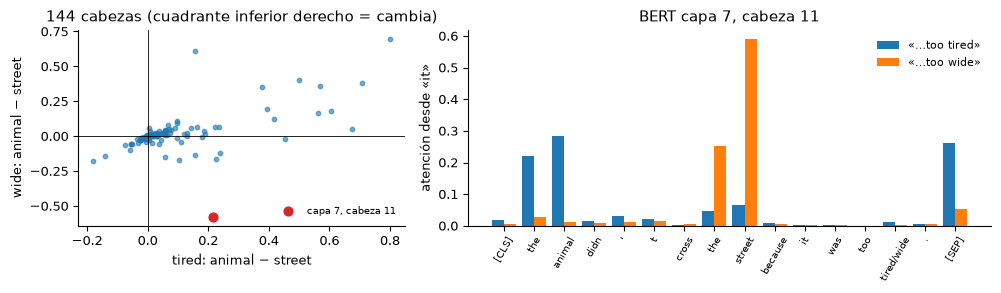

In [12]:
PAIR = {"tired": "The animal didn't cross the street because it was too tired.",
        "wide": "The animal didn't cross the street because it was too wide."}

it_attention = {}
for key, text in PAIR.items():
    att, tokens = get_attentions(bert, tok_bert, text)
    i_it, i_animal, i_street = tokens.index("it"), tokens.index("animal"), tokens.index("street")
    it_attention[key] = {"animal": att[:, :, i_it, i_animal], "street": att[:, :, i_it, i_street],
                         "row": att[:, :, i_it], "tokens": tokens}

diff_tired = it_attention["tired"]["animal"] - it_attention["tired"]["street"]
diff_wide = it_attention["wide"]["street"] - it_attention["wide"]["animal"]
margin = torch.minimum(diff_tired, diff_wide)
flipping = (margin > 0).nonzero().tolist()
ranking = margin.flatten().argsort(descending=True)[:5].tolist()

RESULTS["it_heads"] = {"n_flipping": len(flipping), "top": []}
print(f"cabezas que cambian de antecedente: {len(flipping)} de 144")
for idx in ranking:
    layer, head = divmod(idx, 12)
    row = {"layer": layer + 1, "head": head + 1,
           "tired_animal": it_attention["tired"]["animal"][layer, head].item(),
           "tired_street": it_attention["tired"]["street"][layer, head].item(),
           "wide_animal": it_attention["wide"]["animal"][layer, head].item(),
           "wide_street": it_attention["wide"]["street"][layer, head].item()}
    RESULTS["it_heads"]["top"].append(row)
    print(f"capa {layer + 1:2d} cabeza {head + 1:2d} | tired: animal {row['tired_animal']:.3f} street {row['tired_street']:.3f}"
          f" | wide: animal {row['wide_animal']:.3f} street {row['wide_street']:.3f}")

best_layer, best_head = divmod(ranking[0], 12)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0), gridspec_kw={"width_ratios": [1, 1.6]})
axes[0].scatter(diff_tired.flatten(), -diff_wide.flatten(), s=10, alpha=0.6)
axes[0].scatter(diff_tired[best_layer, best_head], -diff_wide[best_layer, best_head], s=40, color="C3",
                label=f"capa {best_layer + 1}, cabeza {best_head + 1}")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].axvline(0, color="k", lw=0.6)
axes[0].set(xlabel="tired: animal − street", ylabel="wide: animal − street",
            title="144 cabezas (cuadrante inferior derecho = cambia)")
axes[0].legend(frameon=False, fontsize=7.5)
tokens = it_attention["tired"]["tokens"]
positions = np.arange(len(tokens))
for offset, key in ((-0.2, "tired"), (0.2, "wide")):
    axes[1].bar(positions + offset, it_attention[key]["row"][best_layer, best_head], width=0.4, label=f"«…too {key}»")
labels = [t if t not in ("tired", "wide") else "tired/wide" for t in tokens]
axes[1].set_xticks(positions, labels, rotation=60, fontsize=7.5)
axes[1].set(ylabel="atención desde «it»", title=f"BERT capa {best_layer + 1}, cabeza {best_head + 1}")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
save_fig(fig, "05_it_coreference")

**Interpretación.** 22 de las 144 cabezas cambian de antecedente. La más clara es la **capa 7, cabeza 11**: con *tired* «it» atiende 0.28 a «animal» y
0.07 a «street»; con *wide*, 0.01 a «animal» y 0.59 a «street». La mayoría de las cabezas, en cambio, cae en el cuadrante superior derecho (prefieren
«animal», el sujeto, en ambos casos). En GPT-2 esto sería imposible: «it» está antes de *tired/wide* y la máscara causal no le deja ver la palabra que decide.

### 4.3 GPT-2: matriz causal y *attention sinks*

Se comprueba que todo lo que está por encima de la diagonal vale 0 y que cada fila suma 1. Luego se mide qué proporción de la atención
recibe el primer token en cada capa (promedio sobre cabezas y sobre las posiciones 2..n, porque la primera fila solo puede atenderse a sí
misma). Para saber si es por **posición** o por **contenido**, se repite poniendo como primer token palabras distintas y se compara con la
atención que recibe esa misma palabra cuando aparece más adelante.

In [13]:
upper_max, row_error = 0.0, 0.0
first_share_gpt2, first_share_bert, sep_share_bert = [], [], []
for text in SENTENCES:
    att, tokens = get_attentions(gpt2, tok_gpt2, text)
    n = len(tokens)
    upper = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
    upper_max = max(upper_max, att[..., upper].abs().max().item())
    row_error = max(row_error, (att.sum(-1) - 1).abs().max().item())
    first_share_gpt2.append(att[:, :, 1:, 0].mean((1, 2)))
    att_b, tokens_b = get_attentions(bert, tok_bert, text)
    first_share_bert.append(att_b[:, :, :, 0].mean((1, 2)))
    sep_share_bert.append(att_b[:, :, :, -1].mean((1, 2)))

first_share_gpt2 = torch.stack(first_share_gpt2)
first_share_bert = torch.stack(first_share_bert)
sep_share_bert = torch.stack(sep_share_bert)
print(f"máximo por encima de la diagonal = {upper_max:.1e}; error máximo de suma por fila = {row_error:.1e}")
for layer in range(12):
    print(f"capa {layer + 1:2d}: GPT-2 primer token {first_share_gpt2[:, layer].mean():.3f} | "
          f"BERT [CLS] {first_share_bert[:, layer].mean():.3f}, [SEP] {sep_share_bert[:, layer].mean():.3f}")

probe_words = ["The", "Yesterday", "Paris", "However", "Water", "Music"]
sink = {"as_first": [], "as_later": []}
for word in probe_words:
    text = f"{word} people say that {word} is a word like any other, said the {word} expert."
    att, tokens = get_attentions(gpt2, tok_gpt2, text)
    later = [i for i, t in enumerate(tokens) if i > 0 and t == word]
    sink["as_first"].append(att[:, :, later[0]:, 0].mean().item())
    sink["as_later"].append(att[:, :, later[0]:, later[0]].mean().item() if later else float("nan"))
for word, a, b in zip(probe_words, sink["as_first"], sink["as_later"]):
    print(f"{word:10s} recibe {a:.3f} como primer token y {b:.3f} más adelante")

RESULTS["gpt2_causal"] = {"upper_max": upper_max, "row_sum_error": row_error}
RESULTS["first_token_share"] = {"gpt2": first_share_gpt2.mean(0).tolist(), "bert_cls": first_share_bert.mean(0).tolist(),
                                "bert_sep": sep_share_bert.mean(0).tolist()}
RESULTS["sink_probe"] = {"words": probe_words, **sink}

máximo por encima de la diagonal = 0.0e+00; error máximo de suma por fila = 3.0e-07
capa  1: GPT-2 primer token 0.224 | BERT [CLS] 0.133, [SEP] 0.065
capa  2: GPT-2 primer token 0.379 | BERT [CLS] 0.385, [SEP] 0.081
capa  3: GPT-2 primer token 0.372 | BERT [CLS] 0.333, [SEP] 0.094
capa  4: GPT-2 primer token 0.538 | BERT [CLS] 0.250, [SEP] 0.208
capa  5: GPT-2 primer token 0.559 | BERT [CLS] 0.048, [SEP] 0.491
capa  6: GPT-2 primer token 0.724 | BERT [CLS] 0.035, [SEP] 0.579
capa  7: GPT-2 primer token 0.703 | BERT [CLS] 0.036, [SEP] 0.566
capa  8: GPT-2 primer token 0.789 | BERT [CLS] 0.026, [SEP] 0.564
capa  9: GPT-2 primer token 0.704 | BERT [CLS] 0.031, [SEP] 0.560
capa 10: GPT-2 primer token 0.798 | BERT [CLS] 0.065, [SEP] 0.499
capa 11: GPT-2 primer token 0.801 | BERT [CLS] 0.068, [SEP] 0.088
capa 12: GPT-2 primer token 0.659 | BERT [CLS] 0.033, [SEP] 0.058
The        recibe 0.529 como primer token y 0.047 más adelante
Yesterday  recibe 0.516 como primer token y 0.060 más adelant

**Interpretación.** La matriz es exactamente triangular inferior (máximo por encima de la diagonal = 0) y cada fila suma 1. El primer token recibe el 22 %
de la atención en la capa 1 y entre el 70 y el 80 % en las capas 6 a 11. No es por su contenido: cualquier palabra en la primera posición recibe ≈ 0.53,
y esa misma palabra más adelante solo ≈ 0.05. Es un **attention sink** (Xiao et al., 2023): como la softmax obliga a repartir 1, las cabezas que no
necesitan información «estacionan» la atención en un token siempre visible. BERT hace lo mismo con [CLS] (capas 2–4) y [SEP] (capas 5–10).

### 4.4 Entropía de la atención por capa

$H_i=-\sum_j a_{ij}\log a_{ij}$ (en nats) para cada fila. En GPT-2 la fila $i$ solo tiene $i+1$ opciones, así que además se normaliza por
$\log(i+1)$ (1 = uniforme, 0 = toda la atención en un token). En BERT se normaliza por $\log n$.

capa  1: BERT H=2.16 (0.77)  GPT-2 H=1.38 (0.69)
capa  2: BERT H=1.76 (0.62)  GPT-2 H=1.54 (0.75)
capa  3: BERT H=1.54 (0.55)  GPT-2 H=1.38 (0.68)
capa  4: BERT H=1.70 (0.60)  GPT-2 H=1.09 (0.54)
capa  5: BERT H=1.49 (0.53)  GPT-2 H=0.96 (0.47)
capa  6: BERT H=1.22 (0.43)  GPT-2 H=0.83 (0.41)
capa  7: BERT H=1.24 (0.44)  GPT-2 H=0.95 (0.46)
capa  8: BERT H=1.19 (0.42)  GPT-2 H=0.70 (0.34)
capa  9: BERT H=1.42 (0.50)  GPT-2 H=0.95 (0.47)
capa 10: BERT H=1.55 (0.55)  GPT-2 H=0.66 (0.33)
capa 11: BERT H=1.49 (0.53)  GPT-2 H=0.69 (0.34)
capa 12: BERT H=1.55 (0.55)  GPT-2 H=0.97 (0.48)


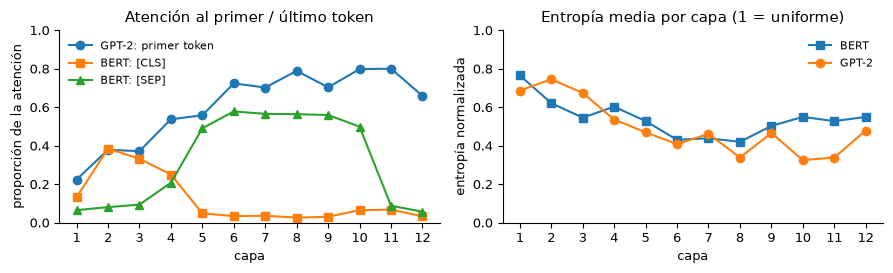

In [14]:
def entropy_by_layer(model, tokenizer, causal):
    raw, normalized = [], []
    for text in SENTENCES:
        att, tokens = get_attentions(model, tokenizer, text)
        n = len(tokens)
        h = -(att * att.clamp_min(1e-12).log()).sum(-1)
        start = 1 if causal else 0
        options = torch.arange(1, n + 1).float() if causal else torch.full((n,), float(n))
        raw.append(h[..., start:].mean((1, 2)))
        normalized.append((h[..., start:] / options[start:].log()).mean((1, 2)))
    return torch.stack(raw).mean(0), torch.stack(normalized).mean(0)


bert_h, bert_hn = entropy_by_layer(bert, tok_bert, causal=False)
gpt2_h, gpt2_hn = entropy_by_layer(gpt2, tok_gpt2, causal=True)
RESULTS["entropy"] = {"bert": bert_h.tolist(), "bert_norm": bert_hn.tolist(),
                      "gpt2": gpt2_h.tolist(), "gpt2_norm": gpt2_hn.tolist()}
layers = np.arange(1, 13)
for l in range(12):
    print(f"capa {l + 1:2d}: BERT H={bert_h[l]:.2f} ({bert_hn[l]:.2f})  GPT-2 H={gpt2_h[l]:.2f} ({gpt2_hn[l]:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].plot(layers, first_share_gpt2.mean(0), "o-", label="GPT-2: primer token")
axes[0].plot(layers, first_share_bert.mean(0), "s-", label="BERT: [CLS]")
axes[0].plot(layers, sep_share_bert.mean(0), "^-", label="BERT: [SEP]")
axes[0].set(xlabel="capa", ylabel="proporción de la atención", title="Atención al primer / último token", ylim=(0, 1))
axes[1].plot(layers, bert_hn, "s-", label="BERT")
axes[1].plot(layers, gpt2_hn, "o-", label="GPT-2")
axes[1].set(xlabel="capa", ylabel="entropía normalizada", title="Entropía media por capa (1 = uniforme)", ylim=(0, 1))
for ax in axes:
    ax.set_xticks(layers)
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save_fig(fig, "06_sinks_entropy")

**Interpretación.** En ambos modelos la entropía baja de la capa 1 (0.77 en BERT, 0.69 en GPT-2) a la capa 8 (0.42 y 0.34): **las capas profundas atienden
de forma más concentrada**. BERT vuelve a abrirse en las últimas capas (0.55), y GPT-2 se mantiene bajo hasta la 11. Parte de esa concentración no es
«atención útil» sino el sink: en las capas profundas la mayoría de la masa va al primer token o a [SEP].

### 4.5 ¿Todas las cabezas son útiles? Ablación en GPT-2

Se apaga una cabeza a la vez (se ponen a cero sus 64 dimensiones antes de la proyección de salida `c_proj`) y se mide cuánto sube la
pérdida de modelado de lenguaje sobre un texto de prueba. Después se apagan juntas las cabezas menos importantes según ese ranking y se mide la
perplejidad en **otro** texto, para no evaluar con el mismo texto con el que se eligieron.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

161 tokens; pérdida base 3.109 (perplejidad 22.4)
cabezas con |Δ| < 0.01: 71; con Δ > 0.1: 6
más importantes (capa, cabeza en base 0): [((0, 0), 2.479933738708496), ((0, 10), 2.0604515075683594), ((5, 1), 0.2756068706512451)]
texto nuevo sin ablación: perplejidad 23.9
texto nuevo, apagando el 10% menos importante: perplejidad 26.9
texto nuevo, apagando el 25% menos importante: perplejidad 30.9
texto nuevo, apagando el 50% menos importante: perplejidad 46.1


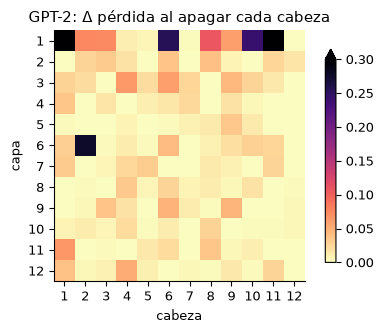

In [15]:
lm = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager").to(DEVICE).eval()
EVAL_TEXT = (
    "The history of the bicycle begins in the early nineteenth century, when inventors in Europe tried to build a machine "
    "that a person could move with their own legs. The first designs had no pedals, and riders pushed the ground with their "
    "feet. Later, pedals were attached to the front wheel, and the wheel became very large to increase speed. These high "
    "wheel bicycles were fast but dangerous, because a small stone could throw the rider over the handlebars. The safety "
    "bicycle, with two wheels of the same size and a chain that moved the rear wheel, solved this problem. It became popular "
    "very quickly, and it changed the way people travelled to work, visited their families and explored the countryside. "
    "Today, millions of people ride bicycles every day, and many cities build special lanes to keep riders safe from cars."
)
HELDOUT_TEXT = (
    "Coffee was first grown in the highlands of Ethiopia, and from there it travelled to Yemen, where people drank it to stay "
    "awake during long nights of prayer. By the seventeenth century, coffee houses had opened in Istanbul, Venice and London. "
    "They were noisy places where merchants, writers and students met to read the news, discuss politics and close business "
    "deals. Some rulers tried to close them, because they feared that people would plan revolts over a cup of coffee, but the "
    "drink was too popular to stop. Later, European countries planted coffee in their colonies in Asia and the Americas, often "
    "with forced labour. Today, Brazil, Vietnam and Colombia are among the largest producers, and coffee is one of the most "
    "traded agricultural products in the world."
)
enc = tok_gpt2(EVAL_TEXT, return_tensors="pt").to(DEVICE)
enc_heldout = tok_gpt2(HELDOUT_TEXT, return_tensors="pt").to(DEVICE)
ablated = set()


def make_hook(layer):
    def hook(module, args):
        heads = [h for l, h in ablated if l == layer]
        if not heads:
            return None
        x = args[0].clone()
        for h in heads:
            x[..., h * 64:(h + 1) * 64] = 0
        return (x,)
    return hook


hooks = [block.attn.c_proj.register_forward_pre_hook(make_hook(l)) for l, block in enumerate(lm.transformer.h)]


def lm_loss(inputs=None):
    inputs = enc if inputs is None else inputs
    with torch.no_grad():
        return lm(**inputs, labels=inputs["input_ids"]).loss.item()


base_loss, heldout_loss = lm_loss(), lm_loss(enc_heldout)
delta = torch.zeros(12, 12)
for l in range(12):
    for h in range(12):
        ablated = {(l, h)}
        delta[l, h] = lm_loss() - base_loss
ablated = set()

order = delta.flatten().argsort().tolist()
prune = {}
for fraction in (0.1, 0.25, 0.5):
    ablated = {divmod(i, 12) for i in order[:int(144 * fraction)]}
    prune[fraction] = lm_loss(enc_heldout)
ablated = set()
for hook in hooks:
    hook.remove()

top = delta.flatten().argsort(descending=True)[:3].tolist()
RESULTS["ablation"] = {"tokens": enc["input_ids"].shape[1], "base_loss": base_loss, "base_ppl": math.exp(base_loss), "heldout_ppl": math.exp(heldout_loss),
                       "delta": delta.tolist(), "n_below_0.01": int((delta.abs() < 0.01).sum()),
                       "n_above_0.1": int((delta > 0.1).sum()), "top": [(divmod(i, 12), delta.flatten()[i].item()) for i in top],
                       "prune_loss": {str(k): v for k, v in prune.items()},
                       "prune_ppl": {str(k): math.exp(v) for k, v in prune.items()}}
print(f"{enc['input_ids'].shape[1]} tokens; pérdida base {base_loss:.3f} (perplejidad {math.exp(base_loss):.1f})")
print(f"cabezas con |Δ| < 0.01: {RESULTS['ablation']['n_below_0.01']}; con Δ > 0.1: {RESULTS['ablation']['n_above_0.1']}")
print("más importantes (capa, cabeza en base 0):", RESULTS["ablation"]["top"])
print(f"texto nuevo sin ablación: perplejidad {math.exp(heldout_loss):.1f}")
for fraction, loss in prune.items():
    print(f"texto nuevo, apagando el {fraction:.0%} menos importante: perplejidad {math.exp(loss):.1f}")

fig, ax = plt.subplots(figsize=(4.6, 3.4))
image = ax.imshow(delta, cmap="magma_r", vmin=0, vmax=0.3)
ax.set_xticks(range(12), range(1, 13))
ax.set_yticks(range(12), range(1, 13))
ax.set(xlabel="cabeza", ylabel="capa", title="GPT-2: Δ pérdida al apagar cada cabeza")
fig.colorbar(image, ax=ax, shrink=0.85, extend="max")
fig.tight_layout()
save_fig(fig, "07_gpt2_ablation")

**Interpretación.** La mitad de las cabezas (71 de 144) cambia la pérdida en menos de 0.01 al apagarla sola y solo 6 la suben más de 0.1. Dos cabezas de la
capa 1 (1 y 11) son críticas (+2.5 y +2.1 nats). En el texto nuevo, apagar juntas el 10 % menos importante sube la perplejidad de 23.9 a 26.9, el 25 % a 30.9
y el 50 % a 46.1: muchas cabezas son redundantes una por una, pero no se pueden quitar todas a la vez (Michel et al., 2019).

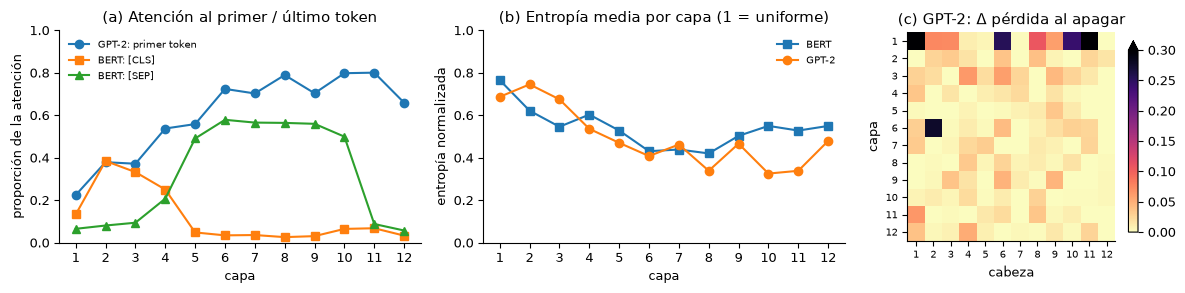

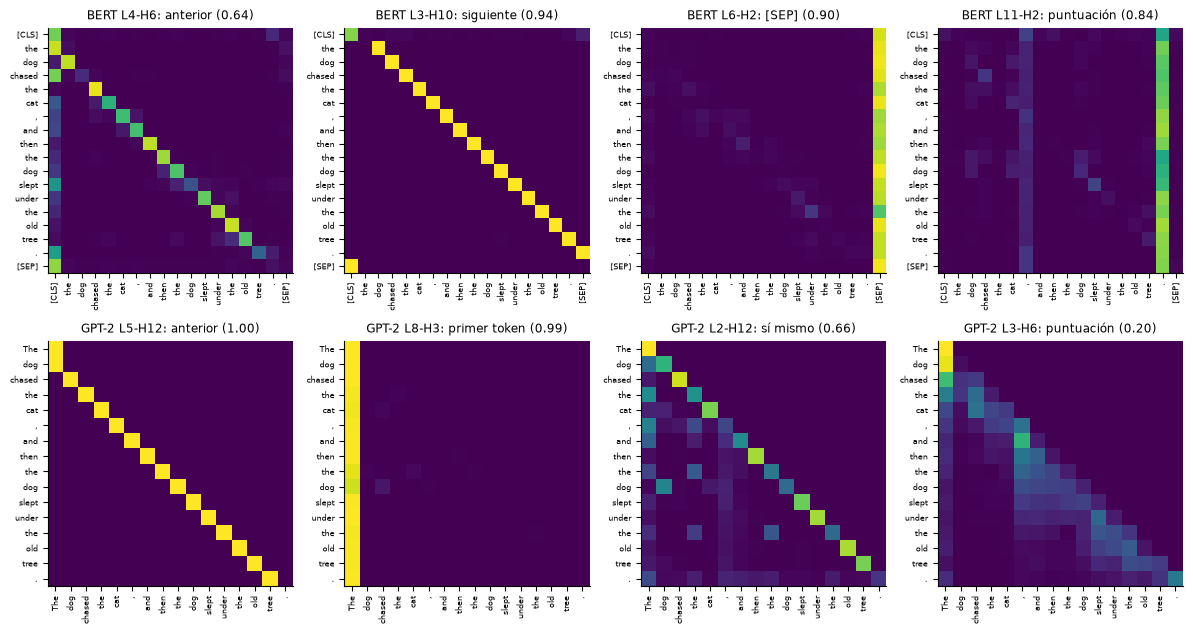

In [16]:
fig = plt.figure(figsize=(12, 3.0))
grid = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.25, 0.9])
ax = fig.add_subplot(grid[0])
ax.plot(layers, first_share_gpt2.mean(0), "o-", label="GPT-2: primer token")
ax.plot(layers, first_share_bert.mean(0), "s-", label="BERT: [CLS]")
ax.plot(layers, sep_share_bert.mean(0), "^-", label="BERT: [SEP]")
ax.set(xlabel="capa", ylabel="proporción de la atención", title="(a) Atención al primer / último token", ylim=(0, 1))
ax.set_xticks(layers)
ax.legend(frameon=False, fontsize=7.5)
ax = fig.add_subplot(grid[1])
ax.plot(layers, bert_hn, "s-", label="BERT")
ax.plot(layers, gpt2_hn, "o-", label="GPT-2")
ax.set(xlabel="capa", ylabel="entropía normalizada", title="(b) Entropía media por capa (1 = uniforme)", ylim=(0, 1))
ax.set_xticks(layers)
ax.legend(frameon=False, fontsize=7.5)
ax = fig.add_subplot(grid[2])
image = ax.imshow(delta, cmap="magma_r", vmin=0, vmax=0.3)
ax.set_xticks(range(12), range(1, 13), fontsize=7)
ax.set_yticks(range(12), range(1, 13), fontsize=7)
ax.set(xlabel="cabeza", ylabel="capa", title="(c) GPT-2: Δ pérdida al apagar")
fig.colorbar(image, ax=ax, shrink=0.9, extend="max")
fig.tight_layout()
save_fig(fig, "08_report_sinks_entropy_ablation")

report_rows = [("BERT", bert_att, bert_tokens, [c for c in bert_chosen if c[0] in ("anterior", "siguiente", "[SEP]", "puntuación")]),
               ("GPT-2", gpt2_att, gpt2_tokens, [c for c in gpt2_chosen if c[0] in ("anterior", "primer token", "sí mismo", "puntuación")])]
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
for row, (model_name, att, tokens, chosen) in zip(axes, report_rows):
    for ax, (pattern, layer, head, score) in zip(row, chosen):
        ax.imshow(att[layer, head], cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(tokens)), tokens, rotation=90, fontsize=6)
        ax.set_yticks(range(len(tokens)), tokens, fontsize=6)
        ax.set_title(f"{model_name} L{layer + 1}-H{head + 1}: {pattern} ({score:.2f})", fontsize=8.5)
fig.tight_layout()
save_fig(fig, "09_report_heads")

### 4.6 Opcional: bertviz

`head_view` genera una vista interactiva de todas las cabezas. Se guarda como HTML en `results/` para abrirla en el navegador
(en Jupyter se puede mostrar directamente con `html_action="view"`).

In [17]:
from bertviz import head_view

for key, text in PAIR.items():
    enc_viz = tok_bert(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        viz_attentions = tuple(a.cpu() for a in bert(**enc_viz).attentions)
    html = head_view(viz_attentions, tok_bert.convert_ids_to_tokens(enc_viz["input_ids"][0]), html_action="return")
    (ROOT / "results" / f"bertviz_{key}.html").write_text(html.data)
print(sorted(p.name for p in (ROOT / "results").glob("bertviz_*.html")))

['bertviz_tired.html', 'bertviz_wide.html']


In [18]:
(ROOT / "results" / "results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False))
print("resultados guardados")

resultados guardados


## Conclusiones

- La atención propia coincide con `F.scaled_dot_product_attention` y `nn.MultiheadAttention` (error ~1e-7).
- Dividir entre √d_k mantiene la varianza de los puntajes en 1 y evita que la softmax se sature y anule el gradiente.
- La atención estándar cuesta O(n²) en tiempo y memoria; FlashAttention conserva el O(n²) en tiempo pero deja la memoria en O(n).
- Las cabezas se especializan (posición, separadores, misma palabra, correferencia), pero muchas son redundantes y gran parte de la atención
  de las capas profundas va a un *sink* (primer token o [SEP]) que no aporta información.
- Por eso los pesos de atención sirven para explorar el modelo, pero no bastan como explicación de sus decisiones.